In [1]:
rm(list = ls())
gc()

library(Seurat)
library(dplyr)

library("SymSim")


setwd('/mnt/data00/Minghui/project_NMF/10_simlate_count/')

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,634147,33.9,1390690,74.3,1064749,56.9
Vcells,1176751,9.0,8388608,64.0,1815604,13.9


Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: plyr

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


Loading required package: ggplot2

Loading required package: Rtsne

Loading r

Using the symSim, we constructed a single-track, single-cell expression dataset spanning normal to cancer. This dataset generated three discrete states (normal, precancerous, and cancer), each containing 5,000 cells, for a total of 6,000 cells. The approach included trajectory simulation, state extraction and construction, noise injection, and batch effect simulation.

In [2]:
library(SymSim)
library(ape)

First, we use SymSim's SimulateTrueCounts() function to simulate a continuous developmental trajectory from "normal" to "cancer", simulating a true transcript count matrix (True counts) of 2000 cells. In this function, the parameter evf_type="continuous" specifies that a continuous cell population should be generated.

In [400]:
# Construct a developmental tree: a short branch Normal and a long branch Cancer


tree_text <- "(Normal:0.01,Cancer:1.0);" 

# The short Normal branch to the “normal” state that has hardly changed
# and the long Cancer branch corresponds to the “normal→cancer” continuous trajectory extending from the root.

tree <- read.tree(text = tree_text)

# Set parameters and simulate real counts
ngenes <- 7000 
true_counts_res <- SimulateTrueCounts(
  ncells_total = 18000,#     The total number of simulated cells is 6000 
#     (to ensure that there are enough cells on the long branches for subsequent
#      selection of 2000 cells at each end).
  ngenes = ngenes,
  evf_type = "continuous", # Generate continuous trajectories
  phyla = tree,
  nevf = 10,
  n_de_evf = 5,
  vary = "s",
  Sigma = 0.4,
  randseed = 123
)

# In addition, the cell development tree parameter phyla is required to define the trajectory structure.

# SymSim uses extrinsic variability factors (EVFs) to characterize biological differences between cells.
# Each cell has an EVF vector, and each gene has a corresponding gene effect vector, 
# which together determine gene expression levels.

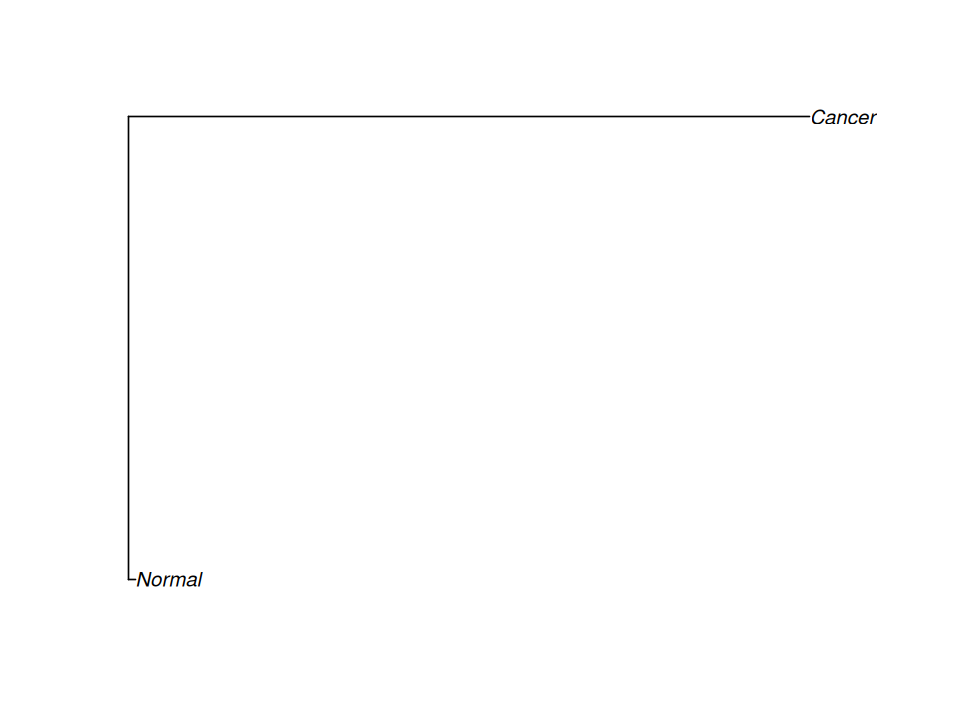

In [551]:
plot(tree)

In the case of continuous trajectories, cells will differentiate continuously along a given trajectory, and the EVF value will change along the tree branches according to the Brownian motion random walk or the pulse model 

In [401]:
# True gene × cell count matrix

true_counts <- true_counts_res[[1]]

# Cell meta-information, including EVF and the branch to which the cell belongs, etc.

cell_meta <- true_counts_res[[3]]         

In [402]:
# Extract continuous trajectory information, 
# returns the "branch" (branch) and "pseudotime" 
# (relative distance/pseudotime from the root) of each cell

traj_info <- getTrajectoryGenes(cell_meta)
head(traj_info)

table(traj_info$branch)

,branch,pseudotime
,<chr>,<dbl>
cell_1,3_1,0.000000e+00
cell_2,3_1,5.617978e-05
cell_3,3_1,1.123596e-04
cell_4,3_1,1.685393e-04
cell_5,3_1,2.247191e-04
cell_6,3_1,2.808989e-04



  3_1   3_2 
  180 17820 

In [403]:
# Find the branch that extends the farthest 
# the Cancer main trajectory branch
max_pstime <- tapply(traj_info$pseudotime, traj_info$branch, max)
main_branch <- names(max_pstime)[which.max(max_pstime)]
main_branch  # e.g., "3_2"


[1] "3_2"

In [408]:
# Extract all cell indices on the main trajectory branch
cells_main_branch <- which(traj_info$branch == main_branch)
# Sort by pseudo time from smallest to largest
cells_main_branch <- cells_main_branch[order(traj_info$pseudotime[cells_main_branch])]

# Select the first 2000 (near the start of the trajectory) and the last 2000 (end)
normal_idx <- cells_main_branch[1:5000]                       # Normal cell index

cancer_idx <- cells_main_branch[(length(cells_main_branch)-4999):length(cells_main_branch)]  # cancer

# Extract the corresponding expression matrix columns

normal_counts <- true_counts[, normal_idx]
cancer_counts <- true_counts[, cancer_idx]


For each simulated precancerous lesion cell, we randomly selected a normal cell and a cancer cell, took a portion of their expression vectors and superimposed them. 

A weighted average method was used:
For each gene, a 0.5 weighted average of the corresponding counts of normal and cancer cells was taken as the base expression value for that gene, and then a certain amount of random noise was added

In [409]:
set.seed(456)
ng <- nrow(true_counts)  # gene number
prec_counts <- matrix(0, nrow=ng, ncol=5000)  # Initialize the precancerous lesion matrix

for(i in 1:5000) {
  # Randomly select a normal cell and a cancer cell
  n_cell <- normal_counts[, sample(ncol(normal_counts), 1)]
  c_cell <- cancer_counts[, sample(ncol(cancer_counts), 1)]
  # Calculate weighted average (50% normal + 50% cancer)
  avg_expr <- 0.5 * n_cell + 0.5 * c_cell
  # Add noise to each gene, here we use Poisson noise as an example
  noisy_expr <- rpois(ng, lambda = avg_expr)
  prec_counts[, i] <- noisy_expr
}
colnames(prec_counts) <- paste0("PrecancerCell", 1:5000)


In [24]:
# In this way, 2000 precancerous cells are generated. 
# We chose the equal weight of 0.5 when weighting so that the expression level of the 
# intermediate state is in the middle of the normal and cancer ends.

In [410]:
#MERGE
combined_counts <- cbind(normal_counts, prec_counts, cancer_counts)
# Create state label vector for merge matrix
cell_labels <- c(rep("Normal", ncol(normal_counts)),
                 rep("Precancer", ncol(prec_counts)),
                 rep("Cancer", ncol(cancer_counts)))

table(cell_labels)

cell_labels
   Cancer    Normal Precancer 
     5000      5000      5000 

The overall expression level of precancerous cells is ensured to be between normal and cancerous. However, due to the introduction of random perturbations, each precancerous cell is not completely located at the center point between normal and cancerous cells, thus forming an independent cluster with internal variation.

In [411]:
# Simulating sequencing technology noise (from true counts to observed counts by using simsym)
# meta_cell data frame
meta_combined <- data.frame(State = cell_labels)

# Randomly generate gene length distribution
set.seed(789)
gene_len <- round(runif(ngenes, min=500, max=5000))

# Convert true counts to observed counts (adding technical noise)
observed_res <- True2ObservedCounts(
  true_counts = combined_counts,
  meta_cell = meta_combined,
  protocol = "UMI",
  alpha_mean = 0.1,
  alpha_sd = 0.002,
  gene_len = gene_len,
  depth_mean = 5e5,
  depth_sd = 1e5,
  lenslope = 0.02,
)

obs_counts <- observed_res[[1]]   # Observation count matrix after adding technical noise
obs_meta <- observed_res[[2]]   #meta info


In [550]:
saveRDS(observed_res ,'./observed_res.rds')

In [498]:
# Divide the observation counts into batches of 15 and include batch effects
batch_res <- DivideBatches(observed_res, nbatch = 15, batch_effect_size =3)
batch_counts <- batch_res[[1]]   # Count matrix with batch effects
batch_meta <- batch_res[[2]]     # meat lable 
table(batch_meta$batch)


   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
 972 1044 1022 1029 1049  936  997  991  972  957  995 1038  991 1017  990 

We choose to assign 5 batches to the Normal state, 4 batches to the Precancer state, and 6 batches to the Cancer state (a total of 5+4+6 = 15 batches).

In [451]:
obs_counts[1:5,1:5]

9,12,6,22,3
6,5,11,15,5
5,4,3,0,0
234,232,216,224,213
0,7,0,1,9


In [499]:
head(batch_meta)

batch_counts[1:5,1:5]

,State,alpha,depth,batch
,<chr>,<dbl>,<dbl>,<int>
1,Normal,0.09998879,459544.4,3
2,Normal,0.09790229,515893.2,11
3,Normal,0.10305208,562337.6,5
4,Normal,0.10201808,531746.0,12
5,Normal,0.09997949,461057.1,8
6,Normal,0.10031094,589923.3,6


6,39,18,21,2
1,0,19,6,4
56,5,20,0,0
225,286,156,69,31
0,73,0,2,7


In [500]:
library(Seurat)
colnames(batch_counts) <- paste0("Cell", seq_len(ncol(batch_counts)))
rownames(batch_counts) <- paste0("Genes", seq_len(nrow(batch_counts)))

rownames(batch_meta) <- colnames(batch_counts)

seurat_obj <- CreateSeuratObject(counts = batch_counts, 
                                 project = "SymSimData", 
                                 meta.data = batch_meta)
seurat_obj


An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 0 variable features)
 2 layers present: counts, data

In [503]:
seurat_obj <- NormalizeData(seurat_obj)  

seurat_obj <- FindVariableFeatures(seurat_obj,selection.method = "vst", nfeatures = 3000 )  

top10 <- head( VariableFeatures(seurat_obj), 10 )
print(top10)

seurat_obj <- ScaleData(seurat_obj)

 [1] "Genes2647" "Genes1168" "Genes5920" "Genes5283" "Genes3285" "Genes2661"
 [7] "Genes6539" "Genes5279" "Genes6350" "Genes6710"


Centering and scaling data matrix



In [504]:
k =20

In [505]:
seurat_obj <- RunPCA(seurat_obj, npcs = k,verbose = FALSE)  

In [506]:
seurat_obj <- FindNeighbors(seurat_obj, dims = 1:k)%>%
 FindClusters()  %>%

 RunUMAP( dims = 1:k) %>% RunTSNE( dims = 1:k)


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 509797

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9576
Number of communities: 30
Elapsed time: 1 seconds


10:11:09 UMAP embedding parameters a = 0.9922 b = 1.112

10:11:09 Read 15000 rows and found 20 numeric columns

10:11:09 Using Annoy for neighbor search, n_neighbors = 30

10:11:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:11:10 Writing NN index file to temp file /tmp/RtmpMXQXYK/file1804ec6e23610e

10:11:10 Searching Annoy index using 1 thread, search_k = 3000

10:11:13 Annoy recall = 100%

10:11:15 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:11:17 Found 15 connected components, 
falling back to 'spca' initialization with init_sdev = 1

10:11:17 Using 'irlba' for PCA

10:11:17 PCA: 2 components explained 15.35% variance

10:11:17 Scaling init to sdev = 1

10:11:17 Commencing optimization for 200 epochs, with 5973

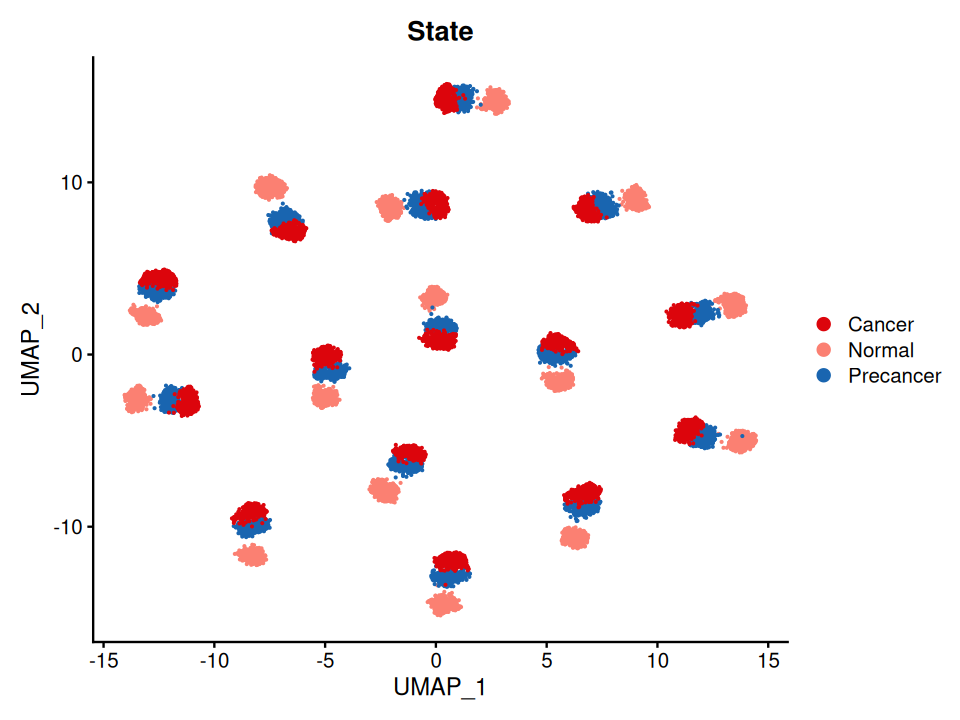

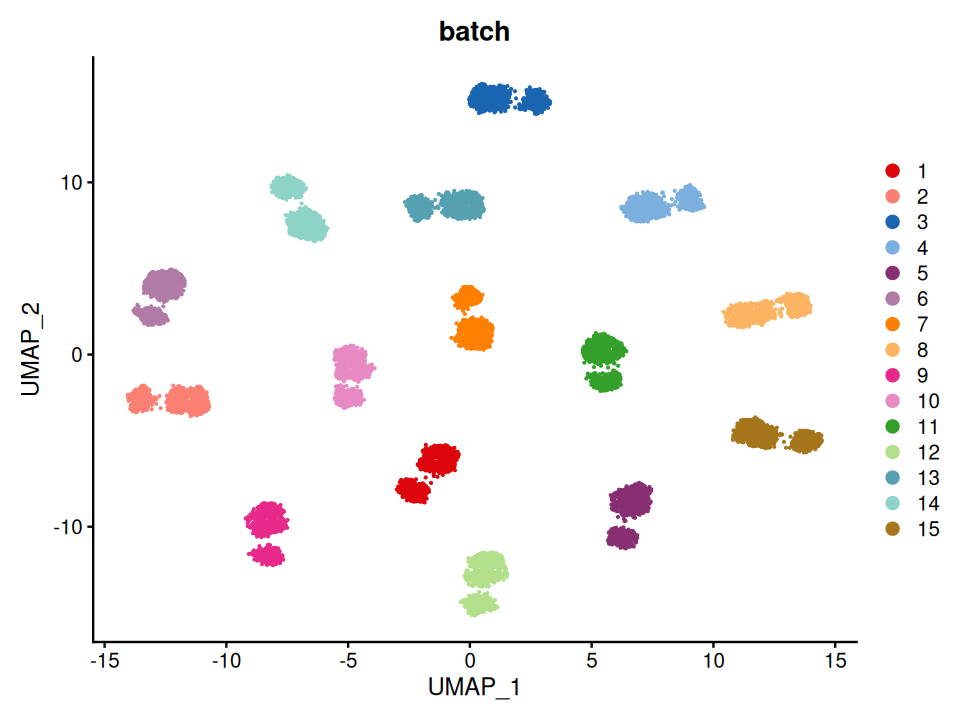

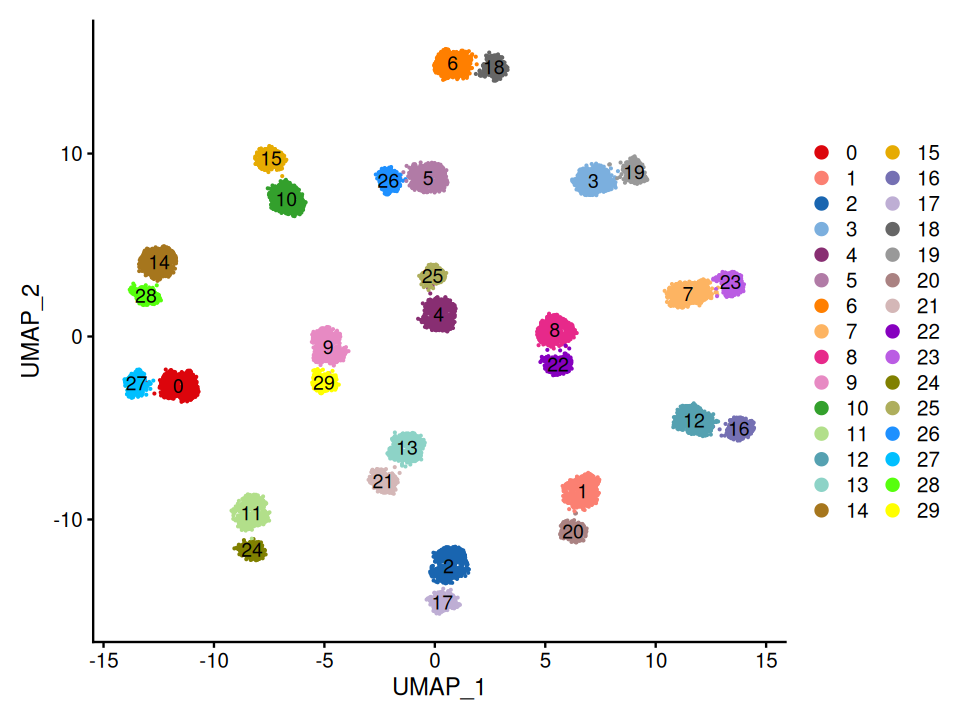

In [507]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj, reduction = "umap", group.by = "State" ,cols = cluster_cols)
DimPlot(seurat_obj, reduction = "umap", group.by = "batch",cols = cluster_cols)
DimPlot(seurat_obj, reduction = "umap", label = TRUE,cols = cluster_cols)  

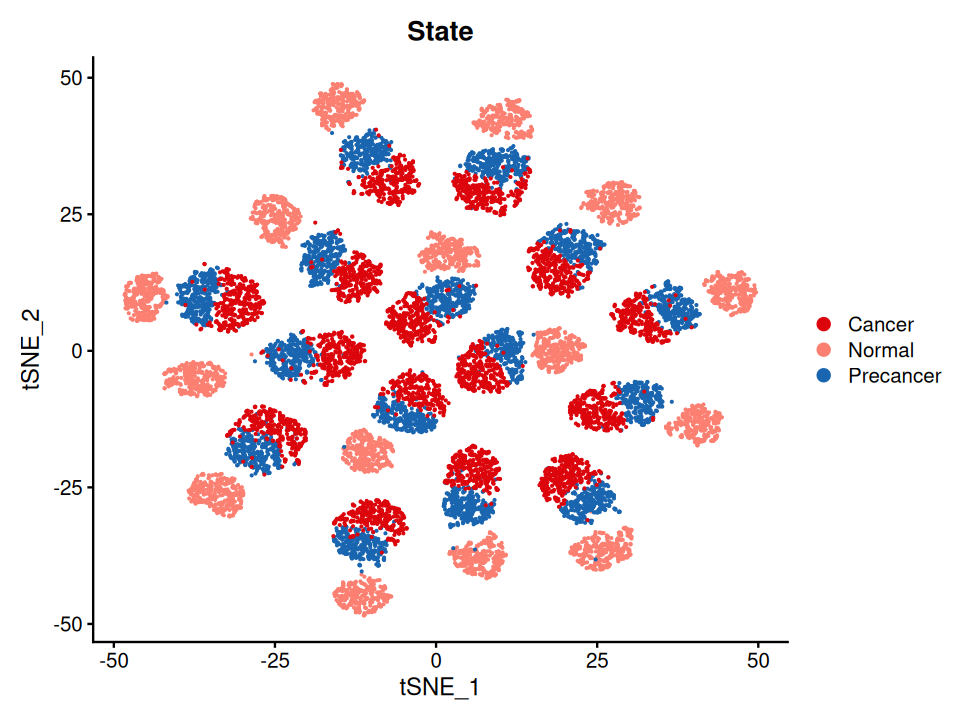

In [508]:
DimPlot(seurat_obj, reduction = "tsne", group.by = "State" ,cols = cluster_cols)


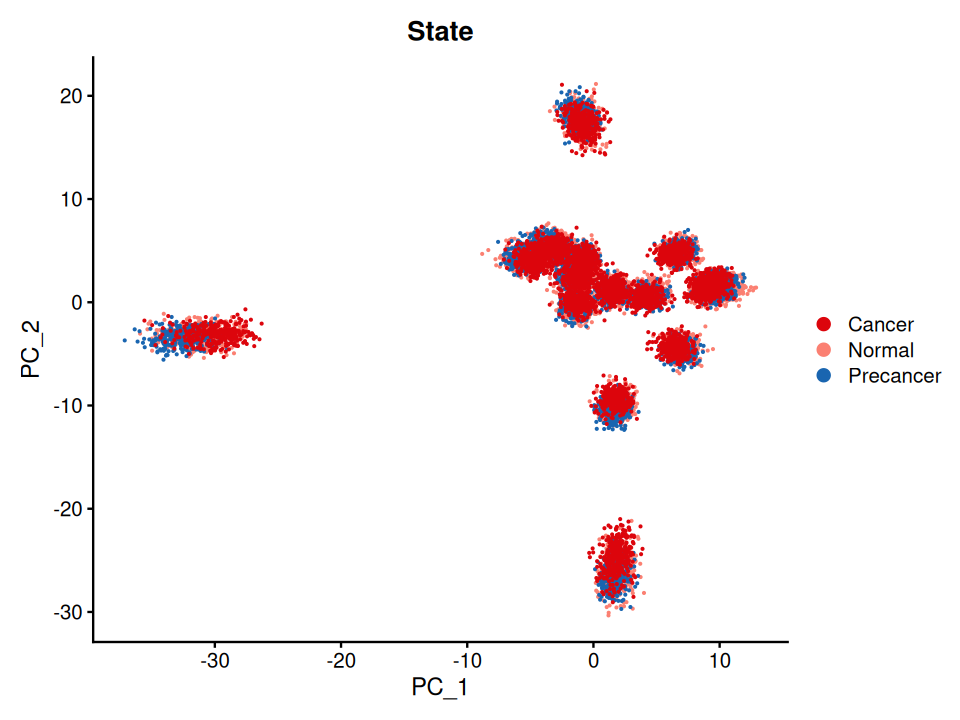

In [512]:
DimPlot(seurat_obj, reduction = "pca", group.by = "State",cols = cluster_cols)


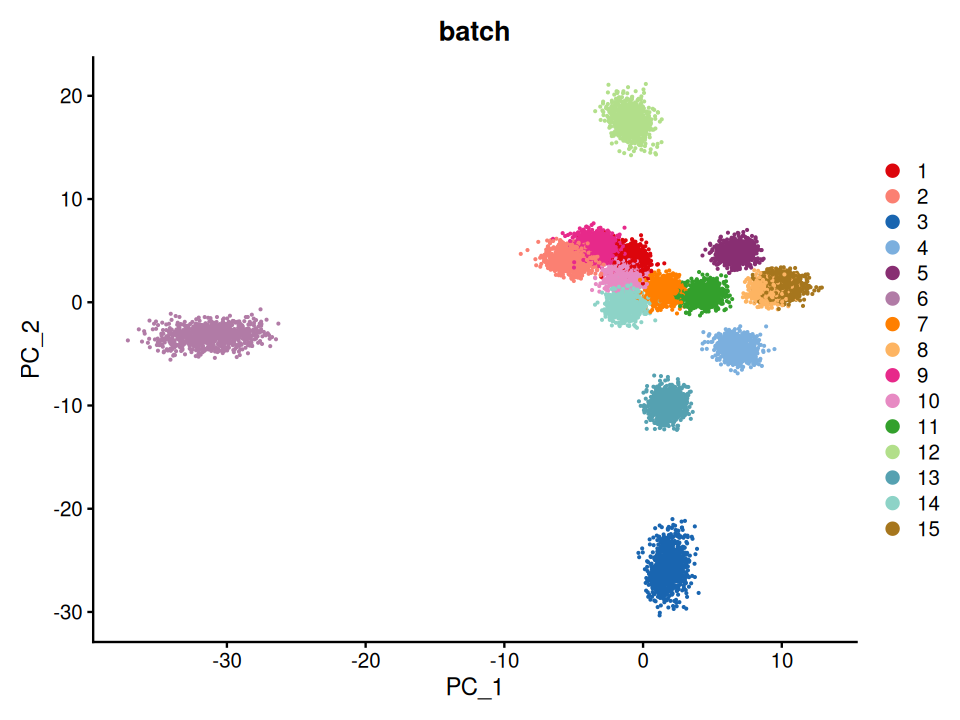

In [513]:
DimPlot(seurat_obj, reduction = "pca", group.by = "batch",cols = cluster_cols)


An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

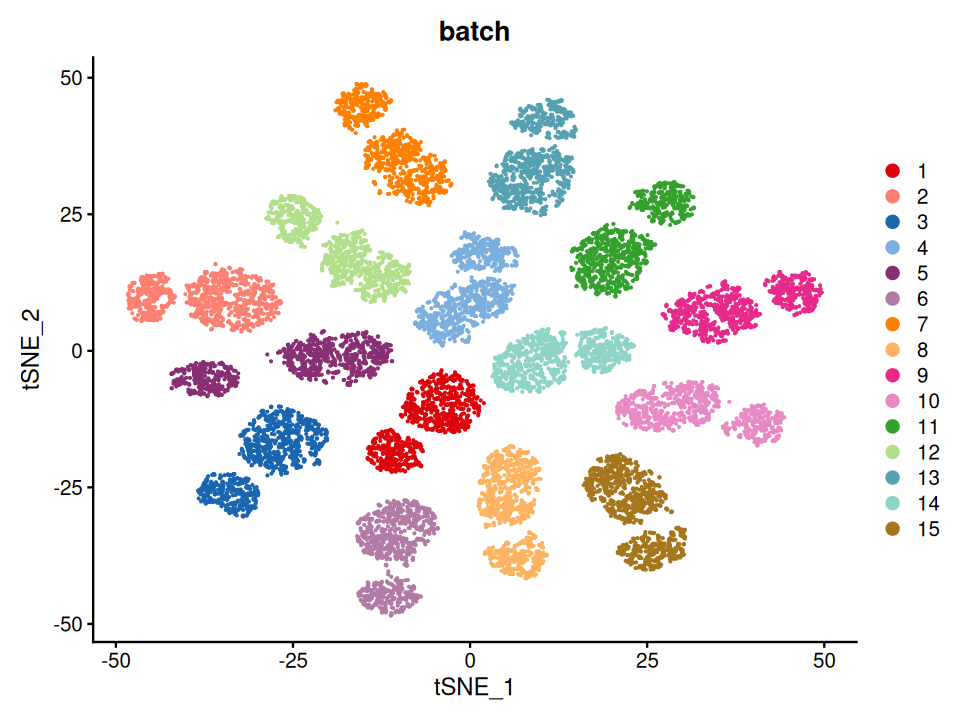

In [515]:
seurat_obj
DimPlot(seurat_obj, reduction = "tsne", group.by = "batch",cols = cluster_cols)


An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

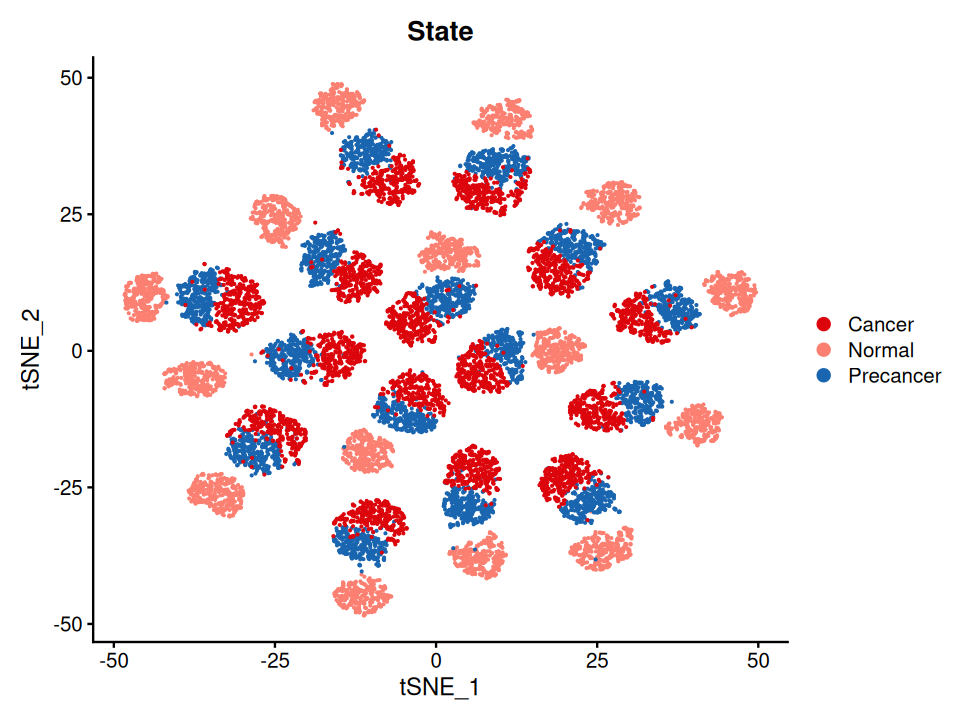

In [549]:
seurat_obj
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj, reduction = "tsne", group.by = "State",cols = cluster_cols)


In [516]:

Idents(seurat_obj) <- 'batch'

split_list <- SplitObject(seurat_obj,split.by = 'batch' )

split_list

$`3`
An object of class Seurat 
7000 features across 1022 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`11`
An object of class Seurat 
7000 features across 995 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`5`
An object of class Seurat 
7000 features across 1049 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`12`
An object of class Seurat 
7000 features across 1038 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`8`
An object of class Seurat 
7000 featur

In [517]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


In [518]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
 Genes100 Genes1000 Genes1001 Genes1002 Genes1004 Genes1005 
       15         4        11        13         8        10 

In [519]:
hvg_freq_df[3000,]

,gene,frequency
,<chr>,<int>
5011,Genes6630,8


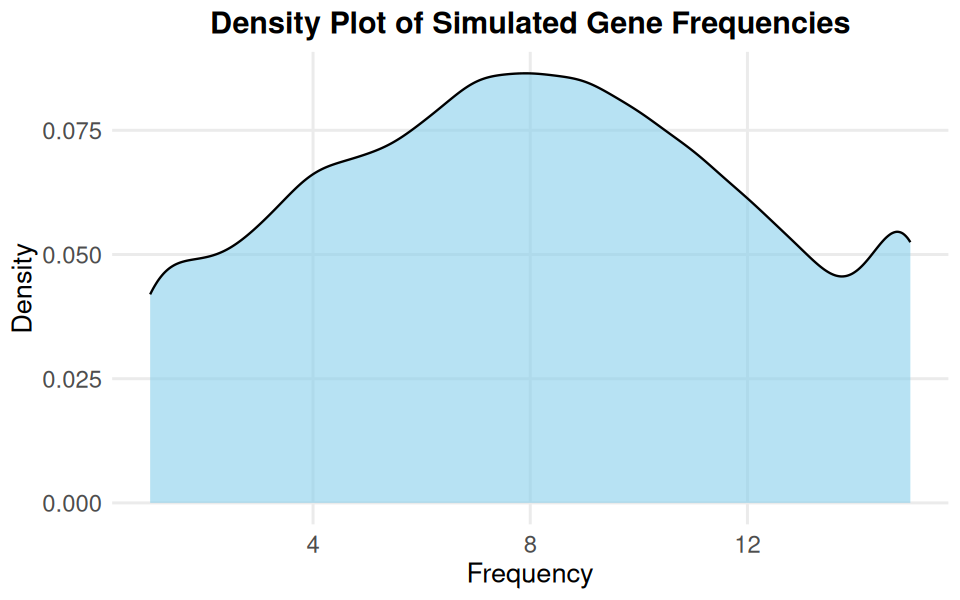

In [520]:
options(repr.plot.width =8, repr.plot.height=5)

ggplot(hvg_freq_df, aes(x = frequency)) +
  geom_density(fill = "skyblue", alpha = 0.6) +
  theme_minimal(base_size = 14) +  
  labs(
    title = "Density Plot of Simulated Gene Frequencies",
    x = "Frequency",
    y = "Density"
  ) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid.minor = element_blank() 
  )


In [522]:
HVGs <- head(hvg_freq_df$gene,3000)

dir <- "/mnt/fast00/Minghui/Simulate_data_06Aug/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  data[data < 0] <- 0
  
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//11/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//5/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//12/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//8/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//6/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//13/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//14/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//10/scaled_matrix.txt


In [532]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 8, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                       3 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/3_k8_theta03_W.csv" 
                                                                      11 
"/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/11_k8_theta03_W.csv" 
                                                                       5 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/5_k8_theta03_W.csv" 
                                                                      12 
"/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/12_k8_theta03_W.csv" 
                                                                       8 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/8_k8_theta03_W.csv" 
                                                                       6 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/6_k8_theta03_W.csv" 
                                                                       4 
 "/mnt/fast00/Minghui/Simulate_data_06

In [533]:
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})


names(w_list) <- names(target_files)


print(names(w_list))


 [1] "3"  "11" "5"  "12" "8"  "6"  "4"  "1"  "2"  "13" "14" "10" "15" "9"  "7" 


In [534]:
gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

names(w_list) <- names(w_list)

In [535]:
merge_matrix <- do.call(cbind ,w_list)
mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns
                

,3_Program_1,3_Program_2,3_Program_3,3_Program_4,3_Program_5,3_Program_6,3_Program_7,3_Program_8,11_Program_1,11_Program_2,⋯,9_Program_7,9_Program_8,7_Program_1,7_Program_2,7_Program_3,7_Program_4,7_Program_5,7_Program_6,7_Program_7,7_Program_8
Genes100,0.0149280632,0.014242513,1.565535e-02,1.781744e-02,2.287209e-02,3.126027e-02,2.016246e-02,8.041395e-03,3.266731e-02,2.078054e-02,⋯,5.404549e-03,0.010399427,8.672524e-03,3.740476e-02,1.976149e-02,2.683745e-03,1.855133e-02,3.893306e-03,0.0121396855,3.006171e-02
Genes1008,0.0126526386,0.007698361,1.978628e-02,2.097344e-02,2.755481e-02,1.064241e-02,1.631315e-02,1.659420e-02,1.178363e-02,7.748904e-03,⋯,2.252560e-02,0.002364962,8.775864e-03,1.609485e-02,1.541014e-02,2.352313e-02,2.616766e-02,2.260263e-02,0.0028517846,1.875421e-02
Genes1018,0.0286889836,0.001200882,9.865199e-10,6.169845e-03,9.566571e-10,9.353977e-10,9.422386e-10,9.236250e-10,9.538925e-10,9.714122e-10,⋯,9.781540e-10,0.032069409,9.733484e-10,9.076208e-10,9.545015e-10,9.423192e-10,9.265210e-10,1.011807e-09,0.0238121950,8.882927e-10
Genes1019,0.0347300463,0.015235652,1.656811e-02,1.653869e-02,2.215411e-02,1.838630e-02,1.316674e-02,1.957480e-02,1.806743e-02,1.225368e-02,⋯,1.487069e-02,0.039034120,1.430978e-02,1.700961e-02,1.368559e-02,1.049937e-02,1.463251e-02,1.427191e-02,0.0394132817,2.355584e-02
Genes1052,0.0003248337,0.101132580,7.150479e-04,9.124695e-10,9.566571e-10,9.353977e-10,3.695011e-05,1.580785e-03,9.538925e-10,1.015183e-02,⋯,9.781540e-10,0.005389765,8.940614e-02,9.076208e-10,9.545015e-10,9.423192e-10,9.265210e-10,1.011807e-09,0.0002759721,8.882927e-10
Genes1056,0.0152253653,0.018461531,9.195786e-03,3.337664e-02,9.566571e-10,6.400054e-03,7.497865e-03,4.179921e-02,1.720298e-04,1.383869e-02,⋯,3.875140e-02,0.010836483,9.733484e-10,3.645822e-03,1.165148e-02,5.198031e-02,1.569045e-02,8.981273e-03,0.0125911863,8.882927e-10


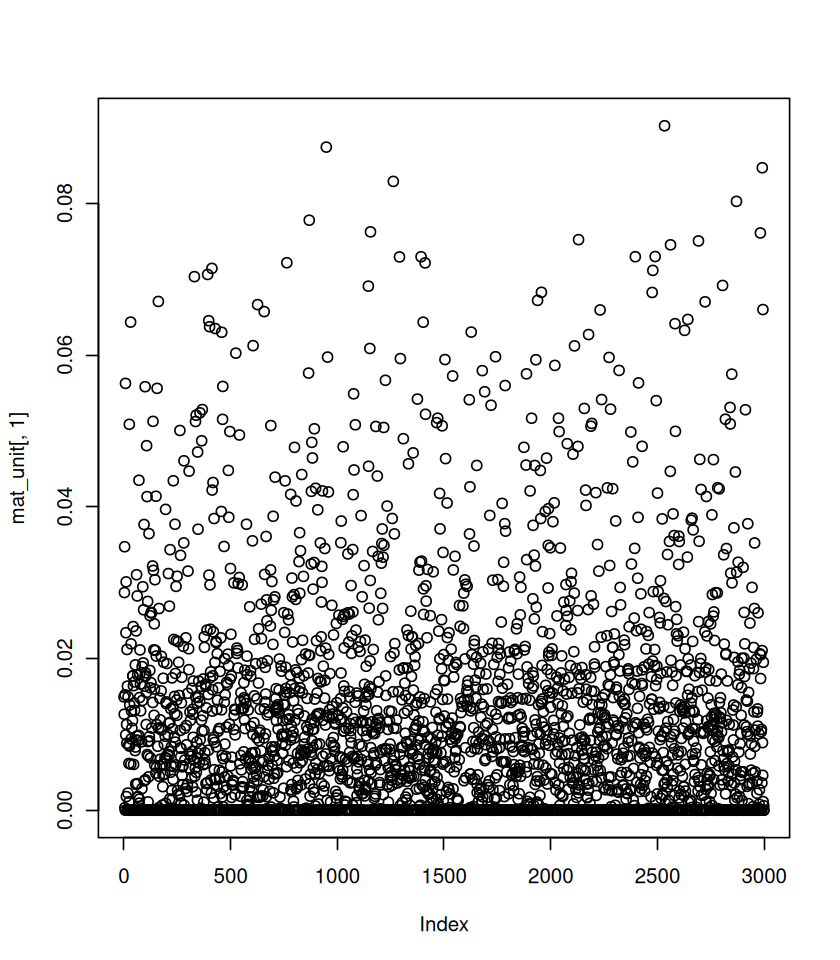

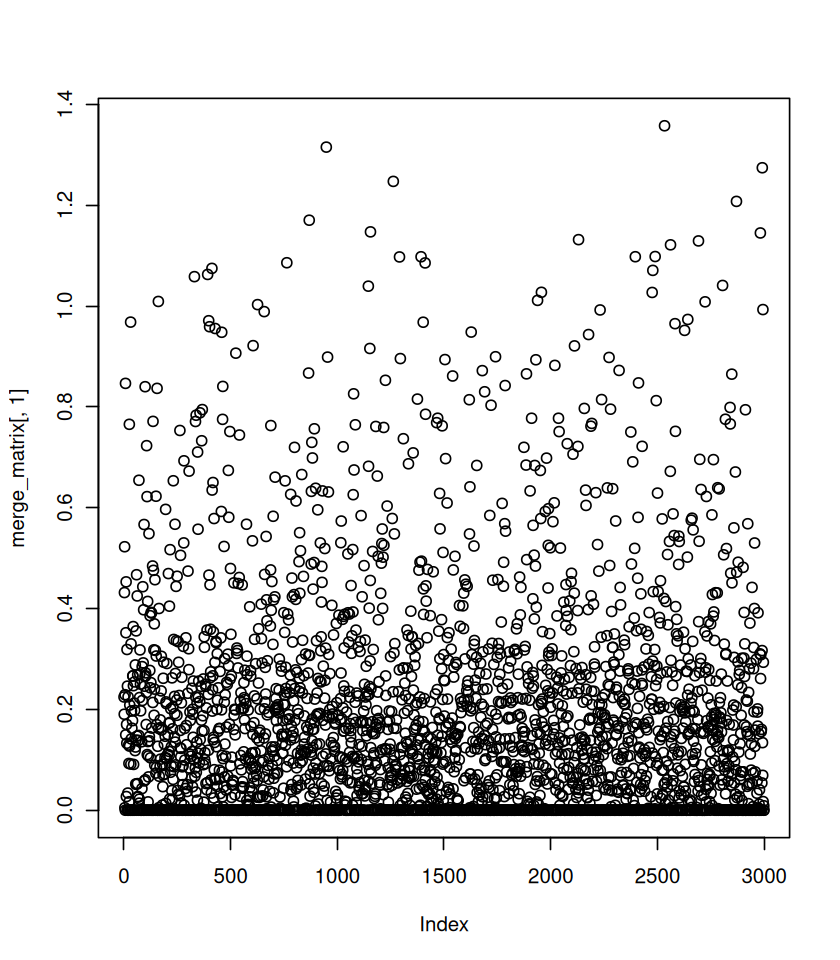

In [536]:
options(repr.plot.width =7, repr.plot.height=8)

head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])


In [537]:
library(cluster)


pam_data <- pam(t(mat_unit),20 )

names(pam_data)

[1] "medoids"    "id.med"     "clustering" "objective"  "isolation" 
 [6] "clusinfo"   "silinfo"    "diss"       "call"       "data"

[1] 0.5627840 0.5889062 0.5568346 0.5754298 0.5534729 0.5544530

[1] 10

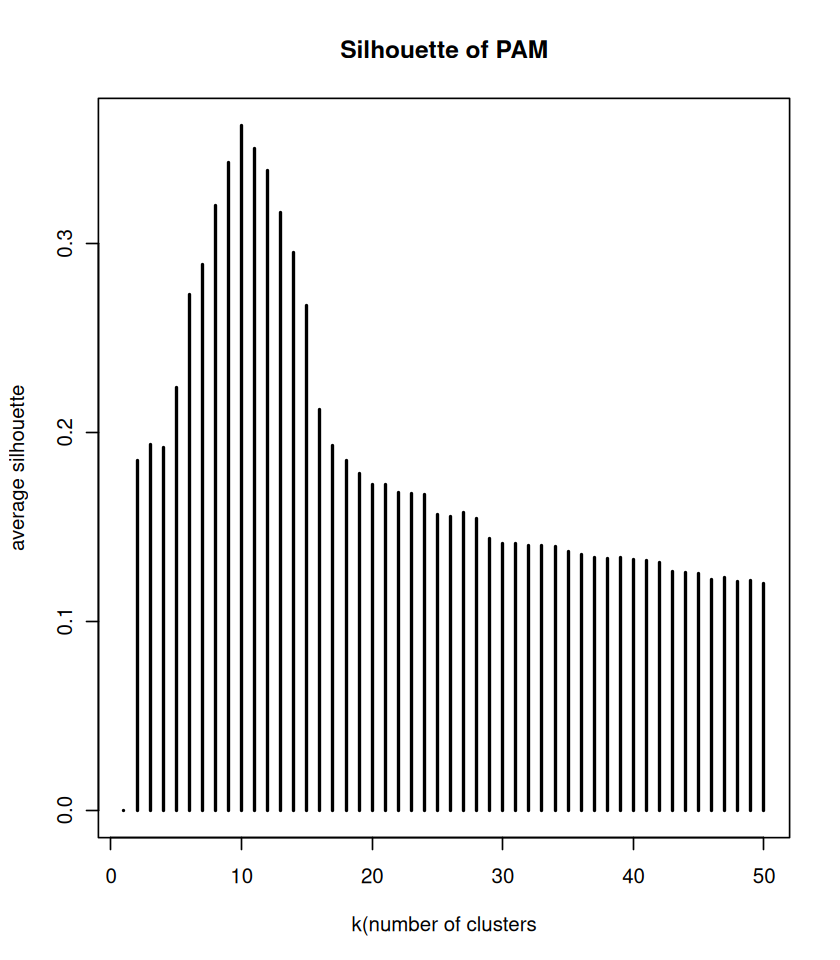

In [538]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

asw <- numeric(50)
for (i in 2:50) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

k.best

In [539]:
k = k.best

pam_data <- pam(t(mat_unit),k )
medoid_names <- pam_data$medoids

medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

names(w_list) <- names(target_files)

print(names(w_list))


 [1] "3"  "11" "5"  "12" "8"  "6"  "4"  "1"  "2"  "13" "14" "10" "15" "9"  "7" 


In [540]:
head(medoid_vectors)

dim(medoid_vectors)

,10_Program_7,13_Program_8,5_Program_3,3_Program_4,13_Program_3,14_Program_7,15_Program_3,6_Program_2,14_Program_4,7_Program_3
Genes100,1.438440e-02,0.013833010,1.927813e-02,1.781744e-02,1.515684e-02,0.0445229789,1.687006e-02,2.475750e-03,1.151611e-02,1.976149e-02
Genes1008,5.665623e-03,0.007835142,2.143591e-02,2.097344e-02,1.793838e-02,0.0065982860,1.505070e-02,9.590494e-03,1.658472e-02,1.541014e-02
Genes1018,4.232117e-02,0.004165593,9.841420e-10,6.169845e-03,9.098349e-10,0.0007200222,9.600646e-10,9.348124e-10,9.436814e-10,9.545015e-10
Genes1019,4.680169e-02,0.015768181,1.858732e-02,1.653869e-02,1.339482e-02,0.0154058822,7.943455e-03,1.627039e-02,1.474223e-02,1.368559e-02
Genes1052,6.306131e-10,0.109603998,9.841420e-10,9.124695e-10,3.589078e-03,0.0028394468,9.600646e-10,5.653791e-07,9.436814e-10,9.545015e-10
Genes1056,1.841570e-02,0.009854560,1.555076e-02,3.337664e-02,5.651417e-03,0.0037930583,5.387184e-03,2.917770e-02,2.269025e-02,1.165148e-02


[1] 3000   10

In [541]:
seurat_sim <- subset(seurat_obj,batch%in% names(w_list))
seurat_sim  <- ScaleData(object = seurat_sim,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- seurat_sim@assays$RNA@scale.data


Scaling data matrix



In [542]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [543]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

In [544]:
seurat_sim[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [545]:
k

[1] 10

In [546]:
# n =30

seurat_sim <- FindNeighbors(seurat_sim, dims = 1:k, reduction = 'Consensus')
seurat_sim <- RunUMAP(seurat_sim, reduction = 'Consensus', dims = 1:k)

seurat_sim <- FindClusters(seurat_sim,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

Computing nearest neighbor graph

Computing SNN

10:22:41 UMAP embedding parameters a = 0.9922 b = 1.112

10:22:41 Read 15000 rows and found 10 numeric columns

10:22:41 Using Annoy for neighbor search, n_neighbors = 30

10:22:41 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:22:42 Writing NN index file to temp file /tmp/RtmpMXQXYK/file1804ec75b6faf4

10:22:42 Searching Annoy index using 1 thread, search_k = 3000

10:22:46 Annoy recall = 100%

10:22:47 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:22:49 Initializing from normalized Laplacian + noise (using irlba)

10:22:49 Commencing optimization for 200 epochs, with 534084 positive edges

10:22:49 Using rng type: pcg

10:22:54 Optimization finished



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 356427

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6309
Number of communities: 22
Elapsed time: 1 seconds


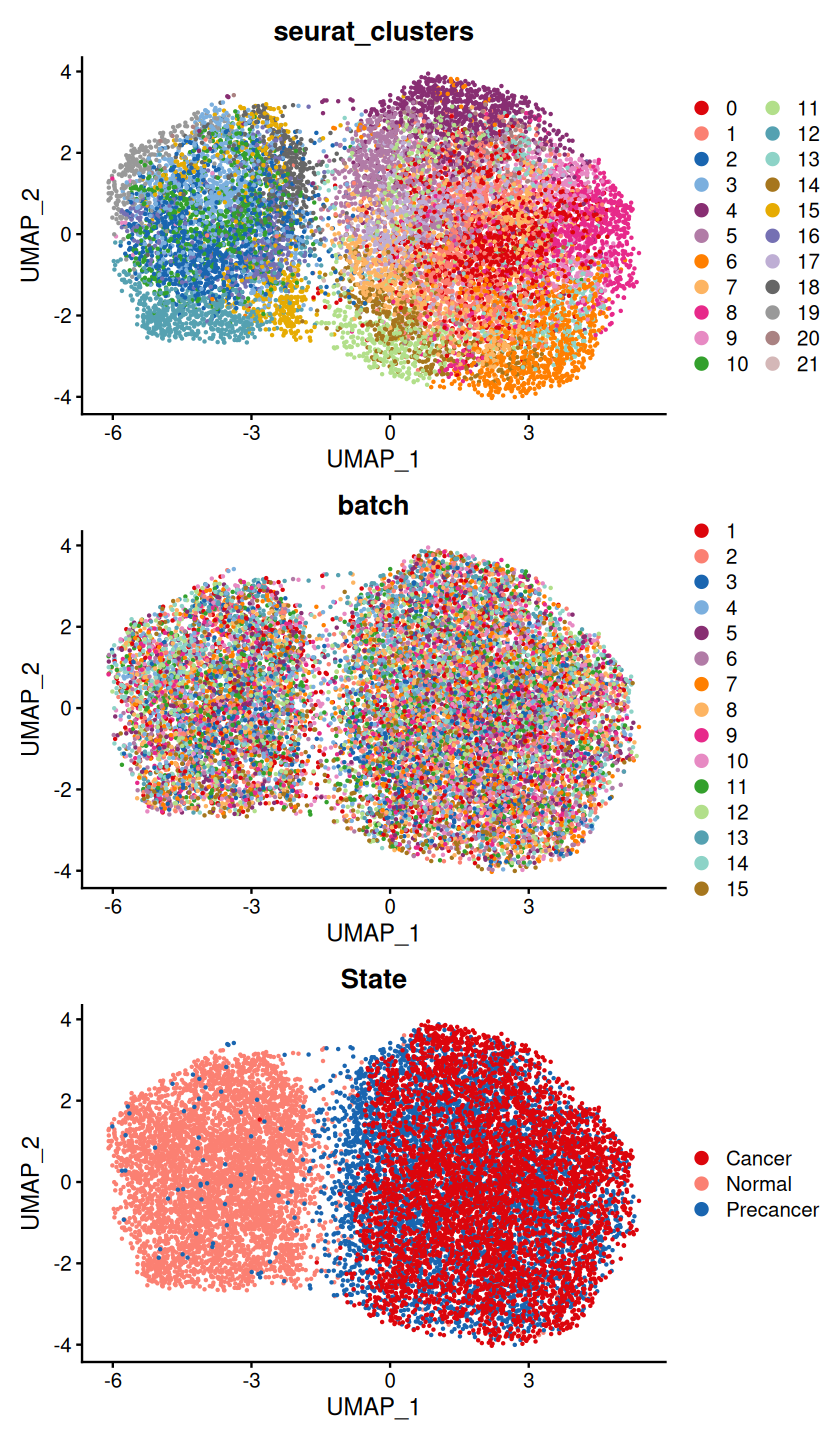

In [547]:
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","batch","State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

In [555]:
library(harmony)

Loading required package: Rcpp



In [557]:
seurat_sim <- RunHarmony(seurat_sim,lambda = 1, group.by.vars = 'batch')

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony converged after 2 iterations



In [558]:
seurat_sim <- RunUMAP(seurat_sim, reduction = 'harmony', dims = 1:k)

10:49:09 UMAP embedding parameters a = 0.9922 b = 1.112

10:49:09 Read 15000 rows and found 10 numeric columns

10:49:09 Using Annoy for neighbor search, n_neighbors = 30

10:49:09 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:49:10 Writing NN index file to temp file /tmp/RtmpMXQXYK/file1804ec43844488

10:49:10 Searching Annoy index using 1 thread, search_k = 3000

10:49:14 Annoy recall = 100%

10:49:15 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:49:17 Found 15 connected components, 
falling back to 'spca' initialization with init_sdev = 1

10:49:17 Using 'irlba' for PCA

10:49:17 PCA: 2 components explained 22.32% variance

10:49:17 Scaling init to sdev = 1

10:49:17 Commencing optimization for 200 epochs, with 6365

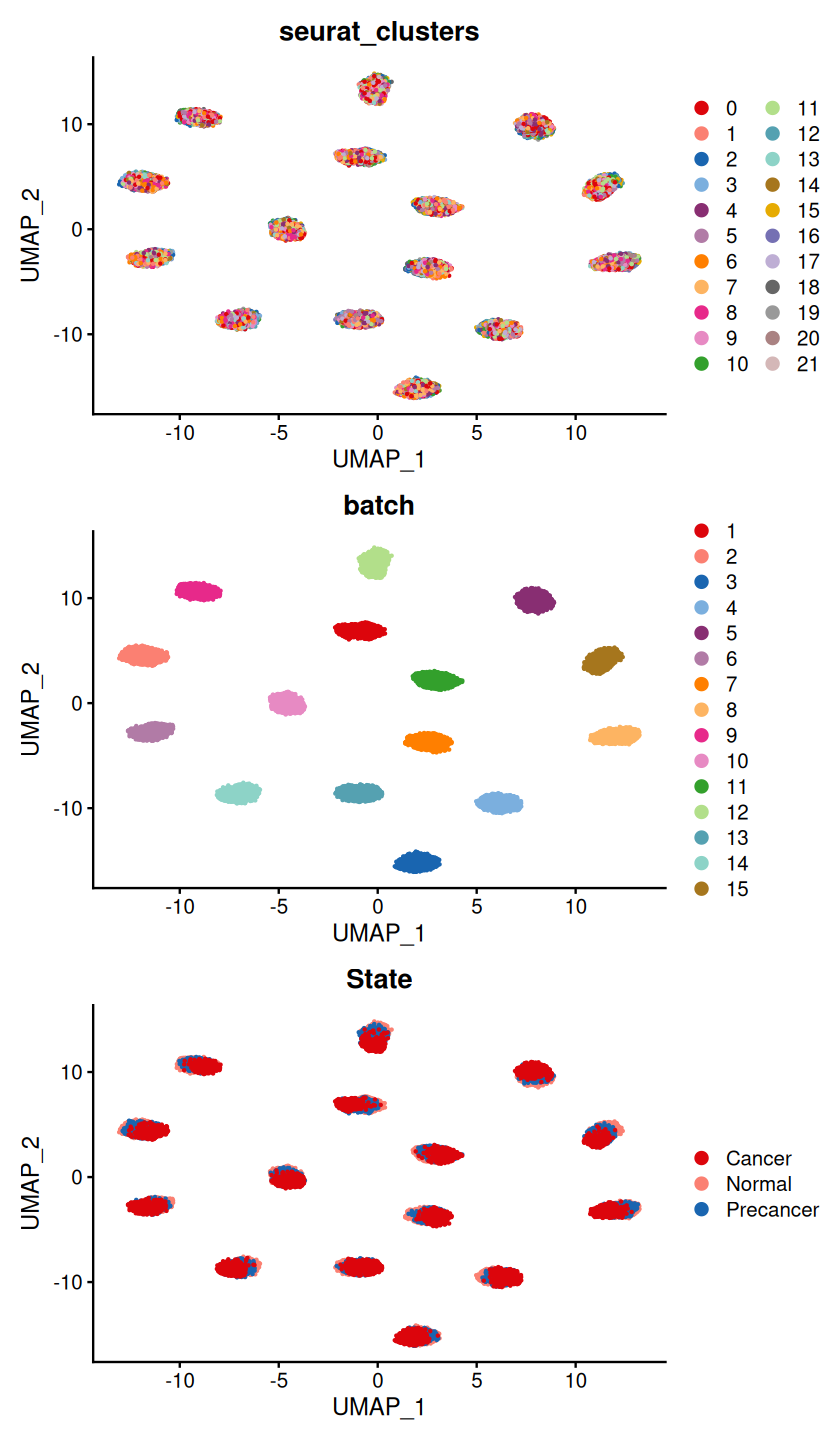

In [559]:
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","batch","State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))